In [59]:
import pandas as pd 
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
iris = datasets.load_iris()

In [60]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [61]:
sc_df = pd.DataFrame()
for k in range(1, 11):
    sc = []
    for i in range(100):
        train, test = train_test_split(df, random_state=i, train_size=0.2)
        X_train, X_test, y_train, y_test = train.drop(["target"], axis=1), test.drop(["target"], axis=1), train[["target"]], test[["target"]]
        neigh = KNeighborsClassifier(n_neighbors=k)
        neigh.fit(X_train.to_numpy(), y_train.to_numpy().squeeze())
        
        sc.append(neigh.score(X_test.to_numpy(), y_test.to_numpy().squeeze()))
    sc_df[str(k)] = sc

In [62]:
sc_df

,1,2,3,4,5,6,7,8,9,10
0,0.925000,0.858333,0.908333,0.883333,0.933333,0.891667,0.916667,0.908333,0.908333,0.900000
1,0.950000,0.916667,0.958333,0.916667,0.933333,0.916667,0.941667,0.941667,0.941667,0.900000
2,0.875000,0.883333,0.883333,0.883333,0.900000,0.891667,0.900000,0.883333,0.891667,0.883333
3,0.908333,0.933333,0.858333,0.883333,0.850000,0.875000,0.841667,0.866667,0.841667,0.916667
4,0.966667,0.941667,0.958333,0.950000,0.966667,0.958333,0.950000,0.958333,0.958333,0.916667
...,...,...,...,...,...,...,...,...,...,...
95,0.933333,0.958333,0.925000,0.916667,0.908333,0.916667,0.925000,0.925000,0.916667,0.916667
96,0.958333,0.958333,0.966667,0.958333,0.966667,0.950000,0.933333,0.933333,0.558333,0.566667
97,0.916667,0.916667,0.933333,0.933333,0.941667,0.933333,0.916667,0.916667,0.916667,0.933333
98,0.883333,0.883333,0.883333,0.883333,0.883333,0.875000,0.883333,0.825000,0.833333,0.783333


[Text(0.5, 0, 'team'), Text(0, 0.5, 'points')]

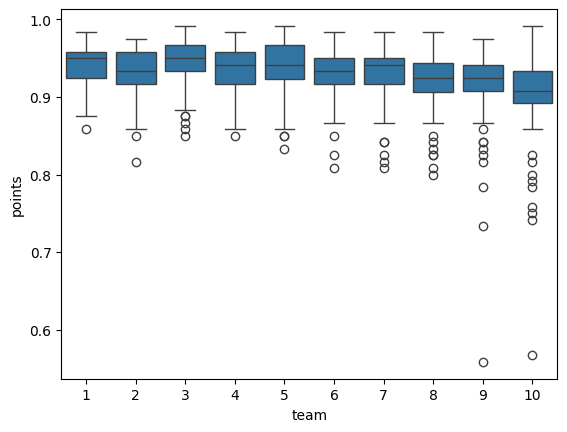

In [63]:
sns.boxplot(x='variable', y='value', data=pd.melt(sc_df)).set ( 
 xlabel='team',  
 ylabel='points')